In [60]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [61]:
%run ./preprocessing.ipynb

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

C:\Users\senp2\AppData\Local\Temp\ipykernel_19584\296921336.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category_columns = df.select_dtypes(include=['object']).columns


In [62]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60


In [63]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [64]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2142,0,0,0,1,21,1,0,0,2,0,2,0,0,2,1,0,3,64.85,1336.800000
1623,0,0,0,0,54,1,2,1,0,2,0,0,2,2,2,1,0,97.20,5129.450000
6074,1,0,1,0,1,0,1,0,0,0,0,0,0,0,0,1,2,23.45,23.450000
1362,1,0,0,0,4,1,0,1,0,0,0,0,0,0,0,1,2,70.20,237.950000
6754,1,0,0,1,0,1,2,0,2,2,0,2,0,0,2,1,0,61.90,2283.300441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,1,0,1,0,1,1,0,1,2,0,0,0,2,2,0,1,2,95.00,95.000000
5191,0,0,1,1,23,1,2,0,2,2,2,2,2,2,2,1,1,91.10,2198.300000
5226,1,0,1,1,12,1,0,2,1,1,1,1,1,1,0,1,2,21.15,306.050000
5390,1,1,0,0,12,1,2,1,0,0,2,0,2,2,0,1,2,99.45,1200.150000


In [65]:
y_train

2142    0
1623    0
6074    1
1362    1
6754    0
       ..
3772    1
5191    0
5226    0
5390    1
860     0
Name: Churn, Length: 5634, dtype: int64

In [66]:
X_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
185,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,1,2,24.80,24.80
2715,1,0,0,0,41,1,2,2,1,1,1,1,1,1,0,1,0,25.25,996.45
3825,0,0,1,1,52,1,0,2,1,1,1,1,1,1,2,0,3,19.35,1031.70
1807,0,0,0,0,1,1,0,1,0,0,2,0,0,0,0,0,2,76.35,76.35
132,1,0,0,0,67,1,0,0,0,0,0,2,0,0,2,0,0,50.55,3260.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6366,0,0,1,0,64,1,0,0,0,2,2,2,0,2,2,1,3,68.30,4378.80
315,1,0,1,1,51,1,2,1,2,2,0,2,2,2,1,0,1,110.05,5686.40
2439,1,0,1,1,17,1,0,2,1,1,1,1,1,1,1,0,0,19.90,329.75
5002,0,0,1,1,69,0,1,0,2,0,2,0,0,2,2,1,1,43.95,2960.10


In [67]:
y_test

185     1
2715    0
3825    0
1807    1
132     0
       ..
6366    0
315     0
2439    0
5002    0
1161    1
Name: Churn, Length: 1409, dtype: int64

In [68]:
from imblearn.over_sampling import SMOTE
from collections import Counter

In [69]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
X_test_balanced, y_test_balanced = smote.fit_resample(X_test, y_test)

In [70]:
print('Before resampling {}'.format(Counter(y_train)))
print('After resample {}'.format(Counter(y_train_balanced)))

Before resampling Counter({0: 4138, 1: 1496})
After resample Counter({0: 4138, 1: 4138})


In [71]:
print('Before resampling {}'.format(Counter(y_test)))
print('After resample {}'.format(Counter(y_test_balanced)))

Before resampling Counter({0: 1036, 1: 373})
After resample Counter({1: 1036, 0: 1036})


In [72]:
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train_balanced, y_train_balanced)
logreg_pred_test = logreg.predict(X_test_balanced)
logreg_pred_train = logreg.predict(X_train_balanced)

In [73]:
accuracy_score(y_test_balanced, logreg_pred_test)

0.8141891891891891

In [74]:
accuracy_score(y_train_balanced, logreg_pred_train)

0.8012324794586757

In [75]:
print(classification_report(y_test_balanced, logreg_pred_test))

              precision    recall  f1-score   support

           0       0.86      0.76      0.80      1036
           1       0.78      0.87      0.82      1036

    accuracy                           0.81      2072
   macro avg       0.82      0.81      0.81      2072
weighted avg       0.82      0.81      0.81      2072



In [76]:
D=pd.DataFrame({'Actual': y_test_balanced, 'Predicted': logreg_pred_test})
W=len(D[D['Actual'] != D['Predicted']])
print("Number of wrong predictions:", W)

Number of wrong predictions: 385


In [77]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train_balanced,y_train_balanced)
y_pred_dt=dt.predict(X_test_balanced)

In [78]:
dt.score(X_test_balanced,y_test_balanced)

0.7688223938223938

In [79]:
dt.score(X_train_balanced,y_train_balanced)

0.998912518124698

In [80]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
grid={'criterion':['entropy','gini'],
     'splitter':['best','random'],
     'min_samples_split':range(2,6,1),
     'min_samples_leaf':range(1,5,1),
     'max_depth':range(1,8),
     'ccp_alpha':np.random.rand(20)}

In [81]:
ranv=RandomizedSearchCV(estimator=dt,param_distributions=grid,cv=10,n_jobs=1)
ranv.fit(X_train_balanced,y_train_balanced)
ranv.best_params_

{'splitter': 'best',
 'min_samples_split': 5,
 'min_samples_leaf': 4,
 'max_depth': 1,
 'criterion': 'gini',
 'ccp_alpha': np.float64(0.04189463476044186)}

In [82]:
dt1=DecisionTreeClassifier(splitter= 'best',
 min_samples_split= 5,
 min_samples_leaf= 1,
 max_depth= 7,
 criterion= 'gini',
 ccp_alpha= np.float64(0.05597663460187563))
dt1.fit(X_train_balanced,y_train_balanced)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"ccp_alpha ccp_alpha: non-negative float, default=0.0Complexity parameter used for Minimal Cost-Complexity Pruning. Thesubtree with the largest cost complexity that is smaller than``ccp_alpha`` will be chosen. By default, no pruning is performed. See:ref:`minimal_cost_complexity_pruning` for details. See:ref:`sphx_glr_auto_examples_tree_plot_cost_complexity_pruning.py`for an example of such pruning... versionadded:: 0.22",np.float64(0....7663460187563)
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of le

In [83]:
y_pred_dt1=dt1.predict(X_test_balanced)

In [84]:
dt1.score(X_test_balanced,y_test_balanced)

0.7582046332046332

In [85]:
dt1.score(X_train_balanced,y_train_balanced)

0.7435959400676655

In [86]:
print(classification_report(y_test_balanced, y_pred_dt1))

              precision    recall  f1-score   support

           0       0.92      0.56      0.70      1036
           1       0.69      0.95      0.80      1036

    accuracy                           0.76      2072
   macro avg       0.80      0.76      0.75      2072
weighted avg       0.80      0.76      0.75      2072



In [87]:
D1=pd.DataFrame({'Actual': y_test_balanced, 'Predicted': y_pred_dt1})
W1=len(D1[D1['Actual'] != D1['Predicted']])
print("Number of wrong predictions:", W1)

Number of wrong predictions: 501


In [88]:
for r in range(10,100,5):
    ran=RandomForestClassifier(n_estimators=r,random_state=42)
    ran.fit(X_train_balanced,y_train_balanced)
    y_pre_ran=ran.predict(X_test_balanced)
    print('for n_estimetor = ',r,'the accuracy is = '+str(accuracy_score(y_test_balanced,y_pre_ran)))

for n_estimetor =  10 the accuracy is = 0.7944015444015444
for n_estimetor =  15 the accuracy is = 0.8045366795366795
for n_estimetor =  20 the accuracy is = 0.8093629343629344
for n_estimetor =  25 the accuracy is = 0.818050193050193
for n_estimetor =  30 the accuracy is = 0.818050193050193
for n_estimetor =  35 the accuracy is = 0.8204633204633205
for n_estimetor =  40 the accuracy is = 0.819015444015444
for n_estimetor =  45 the accuracy is = 0.8204633204633205
for n_estimetor =  50 the accuracy is = 0.8223938223938224
for n_estimetor =  55 the accuracy is = 0.8223938223938224
for n_estimetor =  60 the accuracy is = 0.8252895752895753
for n_estimetor =  65 the accuracy is = 0.8262548262548263
for n_estimetor =  70 the accuracy is = 0.8233590733590733
for n_estimetor =  75 the accuracy is = 0.8243243243243243
for n_estimetor =  80 the accuracy is = 0.8243243243243243
for n_estimetor =  85 the accuracy is = 0.8223938223938224
for n_estimetor =  90 the accuracy is = 0.8223938223938224


In [89]:
ran1=RandomForestClassifier(n_estimators=35,max_depth=8,random_state=42)
ran1.fit(X_train_balanced,y_train_balanced)
y_pre_ran1=ran1.predict(X_test_balanced)

In [90]:
ran1.score(X_test_balanced,y_test_balanced)

0.833011583011583

In [91]:
ran1.score(X_train_balanced,y_train_balanced)

0.861164813919768

In [92]:
print(classification_report(y_test_balanced,y_pre_ran1))

              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1036
           1       0.80      0.89      0.84      1036

    accuracy                           0.83      2072
   macro avg       0.84      0.83      0.83      2072
weighted avg       0.84      0.83      0.83      2072



In [93]:
D3=pd.DataFrame({'Actual': y_test_balanced, 'Predicted': y_pre_ran1})
W3=len(D3[D3['Actual'] != D3['Predicted']])
print("Number of wrong predictions:", W3)

Number of wrong predictions: 346


In [94]:
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
import xgboost
from xgboost import XGBClassifier
ada=AdaBoostClassifier(estimator=ran)
gr=GradientBoostingClassifier(loss='exponential')
xg=XGBClassifier()
l3=[ada,gr,xg]
for i in l3:
    i.fit(X_train_balanced,y_train_balanced)
    print('model = {}'.format(i),' ----- > accuracy =  '+str(i.score(X_test_balanced,y_test_balanced)),' and training accuracy = '+str(i.score(X_train_balanced,y_train_balanced)))
    print()

model = AdaBoostClassifier(estimator=RandomForestClassifier(n_estimators=95,
                                                    random_state=42))  ----- > accuracy =  0.8214285714285714  and training accuracy = 0.998912518124698

model = GradientBoostingClassifier(loss='exponential')  ----- > accuracy =  0.8378378378378378  and training accuracy = 0.8440067665538907

model = XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan

In [95]:
y_pre_ada=ada.predict(X_test_balanced)
y_pre_gr=gr.predict(X_test_balanced)
y_pre_xg=xg.predict(X_test_balanced)
D4=pd.DataFrame({'actual':y_test_balanced,'predicted':y_pre_ada})
W4=len(D4.loc[D4['actual']!=D4['predicted']])
D5=pd.DataFrame({'actual':y_test_balanced,'predicted':y_pre_gr})
W5=len(D5.loc[D5['actual']!=D5['predicted']])
D6=pd.DataFrame({'actual':y_test_balanced,'predicted':y_pre_xg})
W6=len(D6.loc[D6['actual']!=D6['predicted']])
print('Total wrong predictions are [Ada Boost] : '+str(W4))
print('Total wrong predictions are [Gradient Boost] : '+str(W5))
print('Total wrong predictions are [XG Boost] : '+str(W6))

Total wrong predictions are [Ada Boost] : 370
Total wrong predictions are [Gradient Boost] : 336
Total wrong predictions are [XG Boost] : 345


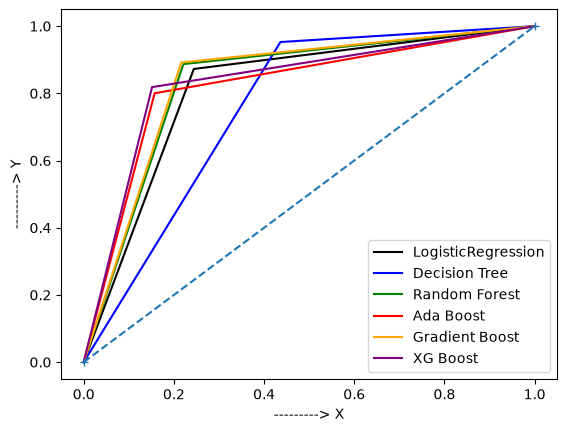

In [96]:
from sklearn.metrics import roc_auc_score, roc_curve
t_log,f_log,th_log=roc_curve(y_test_balanced,logreg_pred_test)
t_dt1,f_dt1,th_dt1=roc_curve(y_test_balanced,y_pred_dt1)
t_ran1,f_ran1,th_ran1=roc_curve(y_test_balanced,y_pre_ran1)
t_ada,f_ada,th_ada=roc_curve(y_test_balanced,y_pre_ada)
t_gr,f_gr,th_gr=roc_curve(y_test_balanced,y_pre_gr)
t_xg,f_xg,th_xg=roc_curve(y_test_balanced,y_pre_xg)
plt.plot(t_log,f_log,color='black',label='LogisticRegression')
plt.plot(t_dt1,f_dt1,color='blue',label='Decision Tree')
plt.plot(t_ran1,f_ran1,color='green',label='Random Forest')
plt.plot(t_ada,f_ada,color='red',label='Ada Boost')
plt.plot(t_gr,f_gr,color='orange',label='Gradient Boost')
plt.plot(t_xg,f_xg,color='purple',label='XG Boost')
plt.plot([0,1],'--',marker='+')
plt.xlabel('---------> X')
plt.ylabel('---------> Y')
plt.legend()
plt.show()

In [97]:
auc_scores={'Logistic Regression': roc_auc_score(y_test_balanced, logreg_pred_test),
             'Decision Tree': roc_auc_score(y_test_balanced, y_pred_dt1),
             'Random Forest': roc_auc_score(y_test_balanced, y_pre_ran1),
             'Ada Boost': roc_auc_score(y_test_balanced, y_pre_ada),
             'Gradient Boost': roc_auc_score(y_test_balanced, y_pre_gr),
             'XG Boost': roc_auc_score(y_test_balanced, y_pre_xg),
             }
print("---- AUC Scores for different models ---")
for model,score in auc_scores.items():
    print(f"{model}:{score:.4f}")
best_model=max(auc_scores,key=auc_scores.get)
print(f"\n the best performing model is : {best_model} with AUC score of {auc_scores[best_model]:.4f}")    

---- AUC Scores for different models ---
Logistic Regression:0.8142
Decision Tree:0.7582
Random Forest:0.8330
Ada Boost:0.8214
Gradient Boost:0.8378
XG Boost:0.8335

 the best performing model is : Gradient Boost with AUC score of 0.8378
